In [1]:
import io
import itertools

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib as mpl

In [ ]:
import pysam

In [ ]:
mpl.rcParams['pdf.fonttype'] = 42   # TrueType
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.size'] = 16 


In [ ]:
p_ctr = '456_ETOH_merged.bam'
p_exp = '456_4OHT_merged.bam'

In [ ]:

def get_idxstats(p):
    stats = pd.read_csv(io.StringIO(pysam.idxstats(p)), 
                        sep='\t', 
                        header=None, 
                        names=['chrom', 'length', 'n_mapped', 'n_unmapped'])
    return stats

# p_ctr = 'Somatic_ATAC_Seq/mergedLibrary/456_ETOH_R2.mLb.clN.sorted.bam'
# p_exp = 'Somatic_ATAC_Seq/mergedLibrary/456_4OHT_R2.mLb.clN.sorted.bam'

# p_ctr = 'Somatic_ATAC_Seq/mergedLibrary/456_ETOH_R1.mLb.clN.sorted.bam'
# p_exp = 'Somatic_ATAC_Seq/mergedLibrary/456_4OHT_R1.mLb.clN.sorted.bam'

# p_ctr = 'Somatic_ATAC_Seq/mergedLibrary/456_ETOH_R3.mLb.clN.sorted.bam'
# p_exp = 'Somatic_ATAC_Seq/mergedLibrary/456_4OHT_R3.mLb.clN.sorted.bam'


f_ctr = pysam.AlignmentFile(p_ctr)
f_exp = pysam.AlignmentFile(p_exp)

# bam = pysam.AlignmentFile(
#     "exp.bam",
#     "rb",
#     threads=12
# )



In [6]:
stats_ctr = get_idxstats(p_ctr)
stats_exp = get_idxstats(p_exp)

n_reads_ctr = stats_ctr.n_mapped.sum()
n_reads_exp = stats_exp.n_mapped.sum()

In [7]:
display(n_reads_ctr)
display(n_reads_exp)

250378352

289028764

In [ ]:
# experimental: use all alignments
lens = [
    r.reference_end - r.next_reference_start
    for r in f_exp
    if r.is_reverse and r.is_mapped and r.mate_is_mapped
]

lens = np.array(lens)


# control: use all alignments
lens1 = [
    r.reference_end - r.next_reference_start
    for r in f_ctr
    if r.is_reverse and r.is_mapped and r.mate_is_mapped
]

lens1 = np.array(lens1)

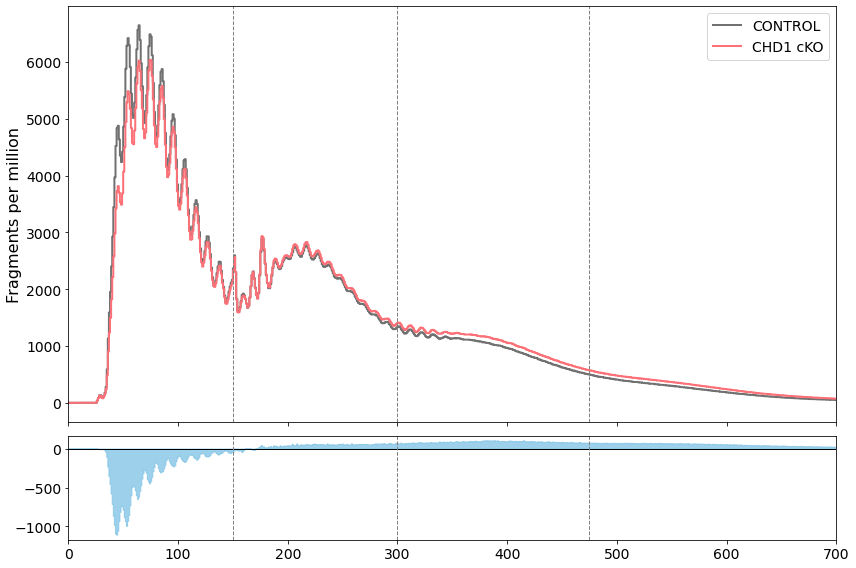

In [10]:
# fragment length distribution for the whole genome (3 replicates merged) (somatic MEFs)

figsize = (12, 8)

# build the common histogram 
bin_edges = np.arange(0, 801, 1)  # 1-bp bins
w_ctl = np.ones_like(lens1, dtype=float) * 1000000 / len(lens1)
w_ko  = np.ones_like(lens,  dtype=float) * 1000000 / len(lens)
cnt_ctl, _ = np.histogram(lens1, bins=bin_edges, weights=w_ctl)
cnt_ko,  _ = np.histogram(lens,  bins=bin_edges, weights=w_ko)

diff = cnt_ko - cnt_ctl
centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# set up two stacked panels
fig, (ax_main, ax_diff) = plt.subplots(
    2, 1, figsize=figsize, sharex=True,
    gridspec_kw={"height_ratios": [4, 1]}  # bottom panel narrower
)

# main histograms 
ax_main.step(centers, cnt_ctl, where='mid', color='#717171', lw=2, label='CONTROL')
ax_main.step(centers, cnt_ko,  where='mid', color='#FC7077', lw=2, label='CHD1 cKO')

ax_main.set_xlim(0, 700)
ax_main.set_ylabel("Fragments per million", fontsize=16)
ax_main.tick_params(axis='both', labelsize=14)
ax_main.legend(fontsize=14, loc='upper right')
ax_main.grid(False)

# vertical guides
for xpos in [150, 300, 475]:
    ax_main.axvline(xpos, color='gray', linestyle='--', linewidth=1)

# difference curve (bottom panel) 
ax_diff.fill_between(centers, diff, 0, step='mid', color='#84C5E6', alpha=0.8)
ax_diff.axhline(0, color='black', linestyle='-', linewidth=1)

# remove axis labels but keep tick labels
ax_diff.set_ylabel("")  # remove y-axis title
ax_diff.set_xlabel("")  # remove x-axis title
ax_diff.tick_params(axis='both', labelsize=14)  # keep tick labels

# vertical guides
for xpos in [150, 300, 475]:
    ax_diff.axvline(xpos, color='gray', linestyle='--', linewidth=1)

plt.tight_layout()

# plt.savefig("/users/uladzis.khauratovich/user_uladzis_khauratovich/pdf_figures_paper_deaft_2025/Fragment_size_SOMATIC_whole_genome_FPM.pdf", dpi=300, bbox_inches="tight", pad_inches=1)


In [3]:
def get_idxstats(p):
    stats = pd.read_csv(io.StringIO(pysam.idxstats(p)), 
                        sep='\t', 
                        header=None, 
                        names=['chrom', 'length', 'n_mapped', 'n_unmapped'])
    return stats

chrX_ctr = '/users/uladzis.khauratovich/groups_SLAVA/Somatic_ATAC_Seq/mergedLibrary/456_ETOH_R2_chrX.bam'
chrX_exp = '/users/uladzis.khauratovich/groups_SLAVA/Somatic_ATAC_Seq/mergedLibrary/456_4OHT_R2_chrX.bam'
chr3_ctr = '/users/uladzis.khauratovich/groups_SLAVA/Somatic_ATAC_Seq/mergedLibrary/456_ETOH_R2_chr3.bam'
chr3_exp = '/users/uladzis.khauratovich/groups_SLAVA/Somatic_ATAC_Seq/mergedLibrary/456_4OHT_R2_chr3.bam'

fX_ctr = pysam.AlignmentFile(chrX_ctr)
fX_exp = pysam.AlignmentFile(chrX_exp)
f3_ctr = pysam.AlignmentFile(chr3_ctr)
f3_exp = pysam.AlignmentFile(chr3_exp)

statsX_ctr = get_idxstats(chrX_ctr)
statsX_exp = get_idxstats(chrX_exp)
stats3_ctr = get_idxstats(chr3_ctr)
stats3_exp = get_idxstats(chr3_exp)

n_reads_chrX_ctr = statsX_ctr.n_mapped.sum()
n_reads_chrX_exp = statsX_exp.n_mapped.sum()
n_reads_chr3_ctr = stats3_ctr.n_mapped.sum()
n_reads_chr3_exp = stats3_exp.n_mapped.sum()

In [4]:
print(n_reads_chr3_ctr)
print(n_reads_chr3_exp)

4336512
6010582


In [5]:
lensXe = [r.reference_end - r.next_reference_start 
 for r in itertools.islice(fX_exp, int(1e7))
 if r.is_reverse and r.is_mapped and r.mate_is_mapped]

lensXe = np.array(lensXe)

lensXc = [r.reference_end - r.next_reference_start 
 for r in itertools.islice(fX_ctr, int(1e7))
 if r.is_reverse and r.is_mapped and r.mate_is_mapped]

lensXc = np.array(lensXc)

lens3e = [r.reference_end - r.next_reference_start 
 for r in itertools.islice(f3_exp, int(1e7))
 if r.is_reverse and r.is_mapped and r.mate_is_mapped]

lens3e = np.array(lens3e)

lens3c = [r.reference_end - r.next_reference_start 
 for r in itertools.islice(f3_ctr, int(1e7))
 if r.is_reverse and r.is_mapped and r.mate_is_mapped]

lens3c = np.array(lens3c)

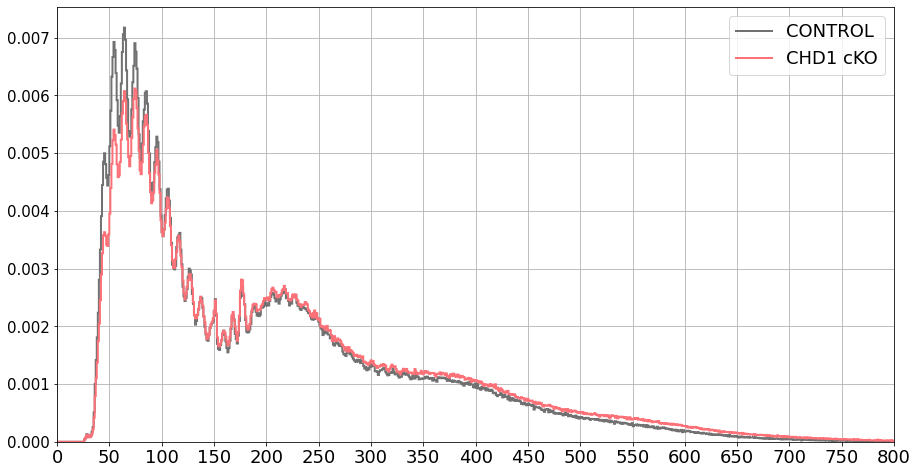

In [28]:
# fragment length distribution for Chromosome 3 (MEFs)

from matplotlib.lines import Line2D

plt.figure(figsize=(15, 8))

# --- your two step histograms (labels suppressed so they don’t auto-enter legend)
plt.hist(lens3c, bins=801, range=(0, 800),
         histtype='step', density=True, color='#717171', lw=2, label='_nolegend_')
plt.hist(lens3e,  bins=801, range=(0, 800),
         histtype='step', density=True, color='#FC7077', lw=2, label='_nolegend_')

# --- custom legend handles: plain Line2D objects -------------------------------
legend_handles = [
    Line2D([0], [0], color='#717171', lw=2, label='CONTROL'),
    Line2D([0], [0], color='#FC7077', lw=2, label='CHD1 cKO')
]

plt.legend(handles=legend_handles, loc='upper right', fontsize=18)

# --- cosmetics (unchanged) -----------------------------------------------------
plt.grid(which='major')
plt.xticks(np.arange(0, 801, 50), fontsize=18)
plt.yticks(fontsize=15)
plt.xlim(0, 800)

# plt.savefig("Destribution_read_length_SOMATIC_my_colours_density.svg", dpi=300, bbox_inches='tight')


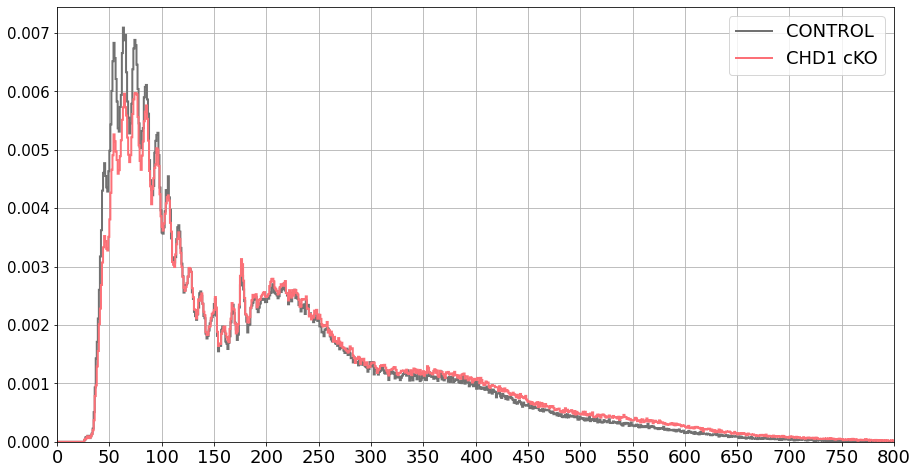

In [34]:
# fragment length distribution for Chromosome X (MEFs)

from matplotlib.lines import Line2D

plt.figure(figsize=(15, 8))

# --- your two step histograms (labels suppressed so they don’t auto-enter legend)
plt.hist(lensXc, bins=801, range=(0, 800),
         histtype='step', density=True, color='#717171', lw=2, label='_nolegend_')
plt.hist(lensXe,  bins=801, range=(0, 800),
         histtype='step', density=True, color='#FC7077', lw=2, label='_nolegend_')

# --- custom legend handles: plain Line2D objects -------------------------------
legend_handles = [
    Line2D([0], [0], color='#717171', lw=2, label='CONTROL'),
    Line2D([0], [0], color='#FC7077', lw=2, label='CHD1 cKO')
]

plt.legend(handles=legend_handles, loc='upper right', fontsize=18)

# --- cosmetics (unchanged) -----------------------------------------------------
plt.grid(which='major')
plt.xticks(np.arange(0, 801, 50), fontsize=18)
plt.yticks(fontsize=15)
plt.xlim(0, 800)

# plt.savefig("Destribution_read_length_SOMATIC_ChrX_my_colours_density.svg", dpi=300, bbox_inches='tight')
